### Business Problem:
Customer churn poses a significant threat to Telco companies, impacting revenue and growth. This project aims at identifying customers at high risk of churning and understanding the underlying reasons to develop effective retention strategies. This project aims to build a predictive model to accurately forecast customer churn and provide actionable insights, enabling the company to proactively engage and retain valuable customers.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/sample_data/Telco_Consumer_Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#Total Charges column changing to numeric for analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [6]:
#drop any duplicate columns (none identified)
initial_rows = len(df)
df.drop_duplicates(inplace=True)
rows_after_dropping = len(df)

print(f"Initial rows:{initial_rows}")
print(f"Rows after dropping duplicates:{rows_after_dropping}")
print(f"Rows removed:{initial_rows - rows_after_dropping}")

Initial rows:7043
Rows after dropping duplicates:7043
Rows removed:0


## Analyze Churn Rates

For all relevant columns, calculating the churn rate (percentage of churn vs no churn) for each unique column. This will help identify categories with higher churn probability

In [7]:
#Looking at all the categorial columns for Churn calculation
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')
print("categorical columns:")
print(categorical_cols)

categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [8]:
#Churn rates by categorial features
print("Churn Rates by Categorical Features:")
churn_rates = {}

cols = [col for col in categorical_cols if col != 'Churn']

for col in cols:
    grouped_data = df.groupby([col, 'Churn']).size().unstack(fill_value=0)

    grouped_data['Yes'] = grouped_data['Yes']
    grouped_data['Churn_Rate'] = (grouped_data['Yes'] / (grouped_data['No'] + grouped_data['Yes'])) * 100

    churn_rates[col] = grouped_data['Churn_Rate']

    print(f"\n Churn Rate by {col}")
    print(grouped_data[['Yes', 'No', 'Churn_Rate']])

Churn Rates by Categorical Features:

 Churn Rate by gender
Churn   Yes    No  Churn_Rate
gender                       
Female  939  2549   26.920872
Male    930  2625   26.160338

 Churn Rate by Partner
Churn     Yes    No  Churn_Rate
Partner                        
No       1200  2441   32.957979
Yes       669  2733   19.664903

 Churn Rate by Dependents
Churn        Yes    No  Churn_Rate
Dependents                        
No          1543  3390   31.279140
Yes          326  1784   15.450237

 Churn Rate by PhoneService
Churn          Yes    No  Churn_Rate
PhoneService                        
No             170   512   24.926686
Yes           1699  4662   26.709637

 Churn Rate by MultipleLines
Churn             Yes    No  Churn_Rate
MultipleLines                          
No                849  2541   25.044248
No phone service  170   512   24.926686
Yes               850  2121   28.609896

 Churn Rate by InternetService
Churn             Yes    No  Churn_Rate
InternetService       

### Visualize the Churn rates by categorial features

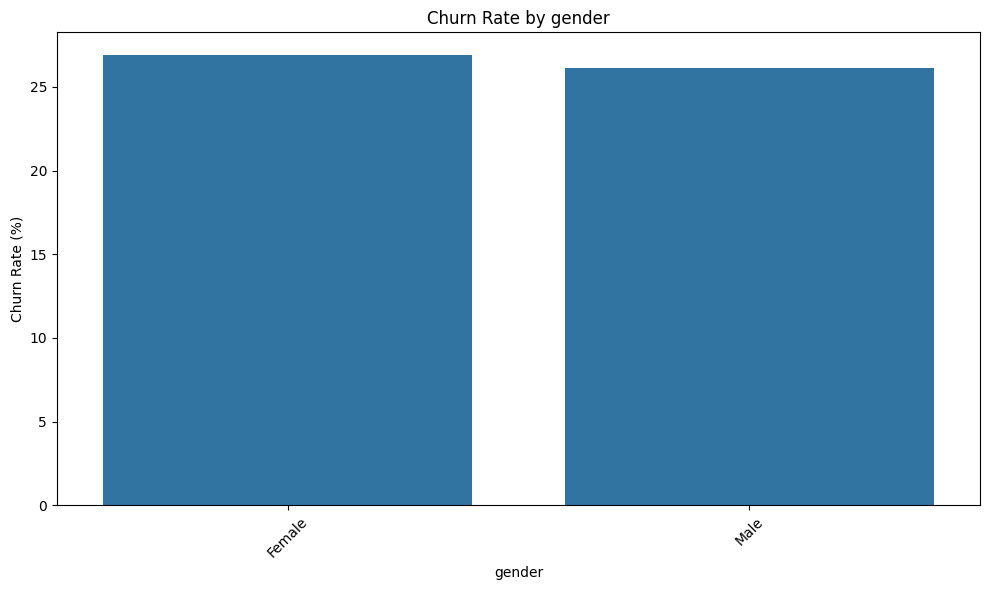

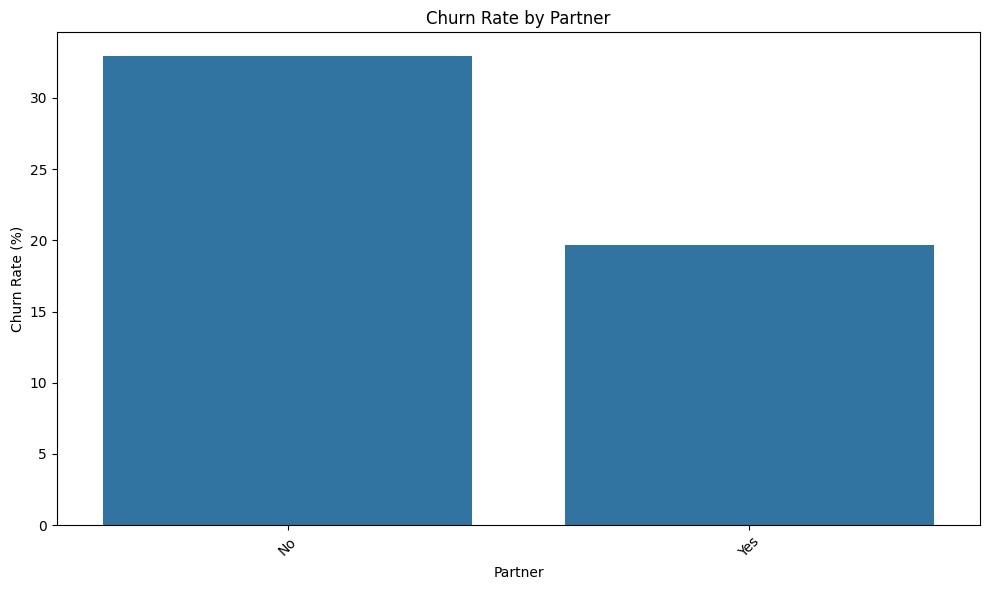

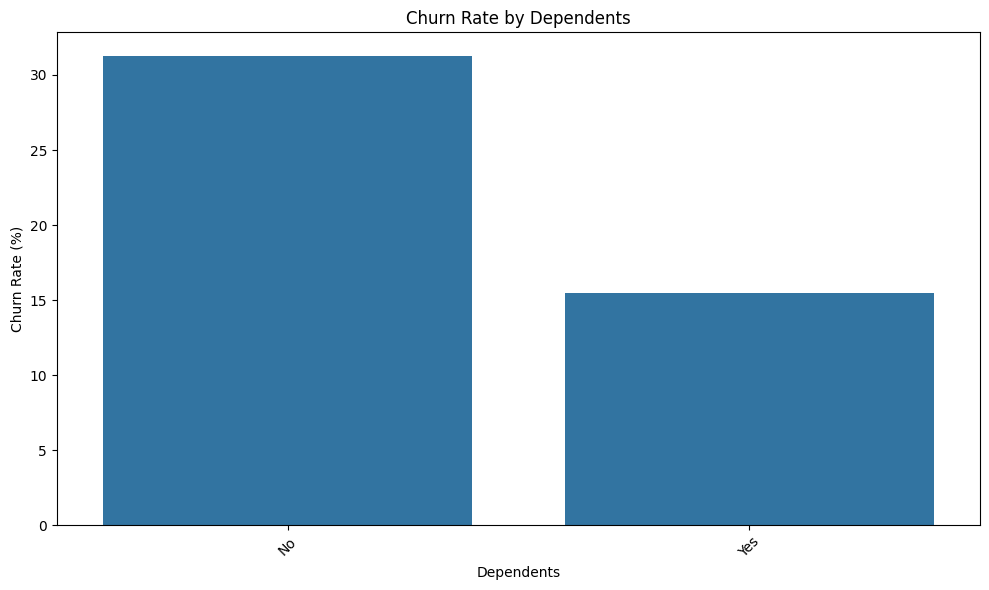

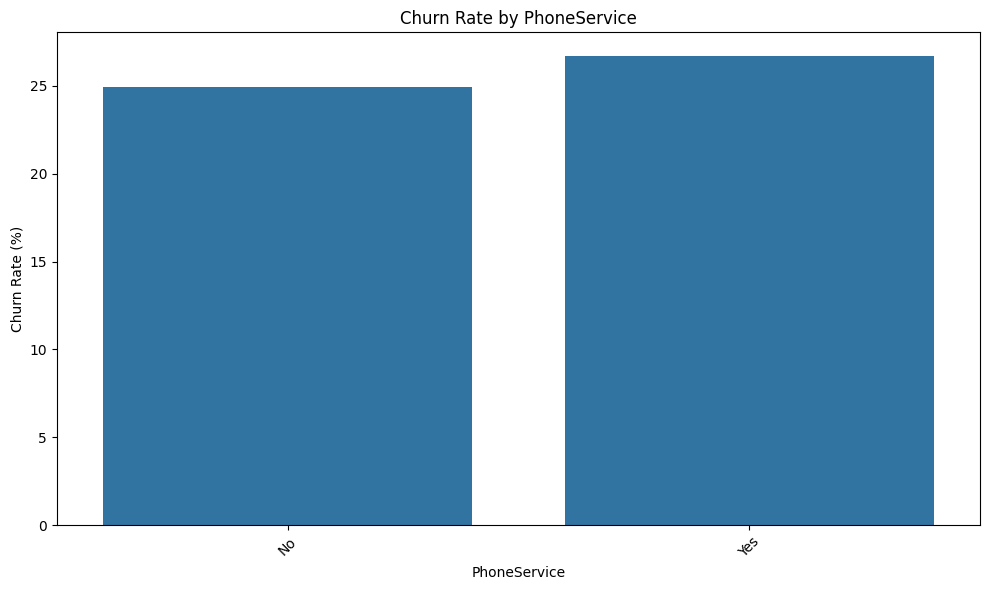

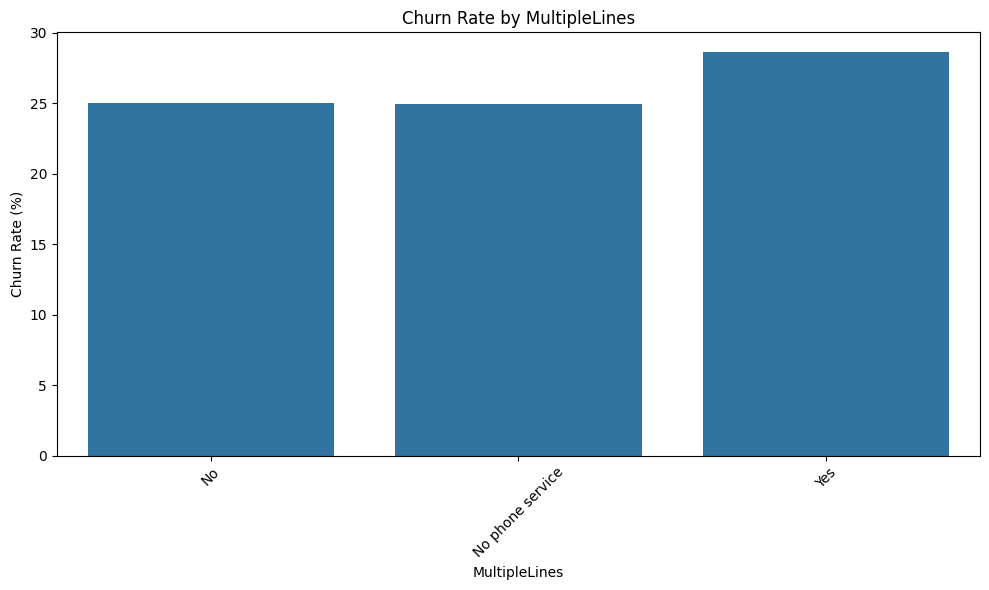

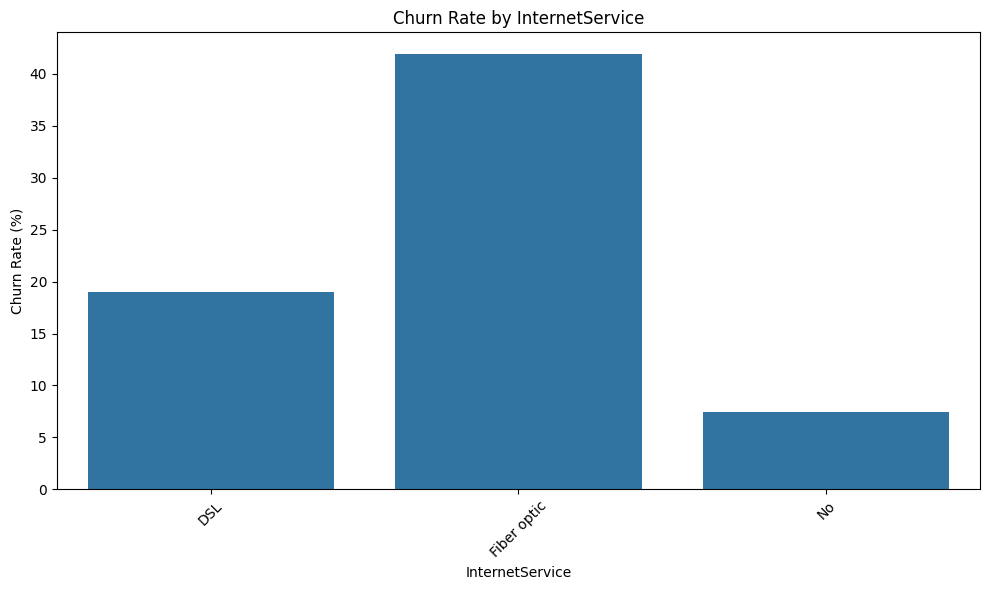

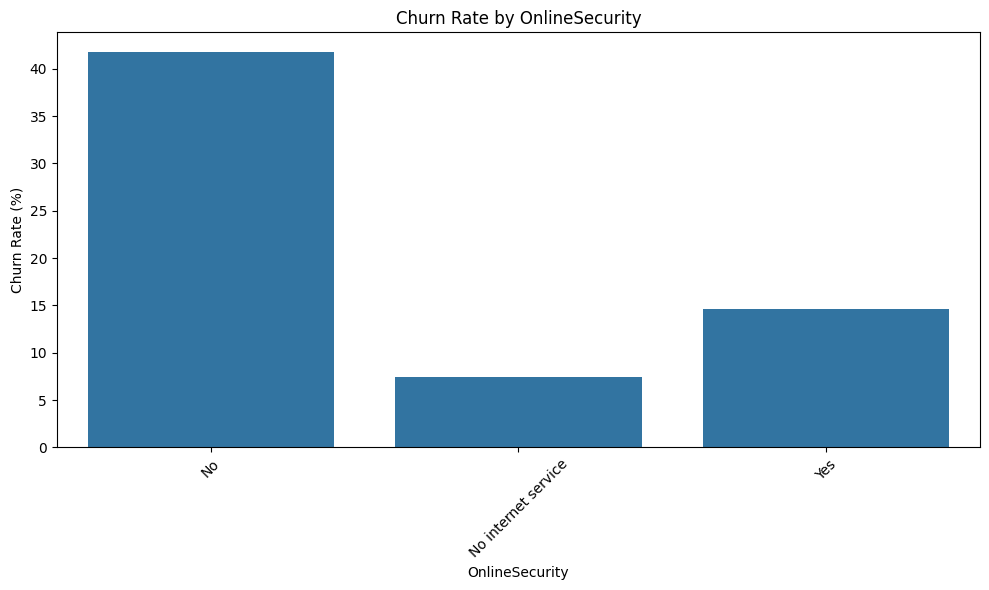

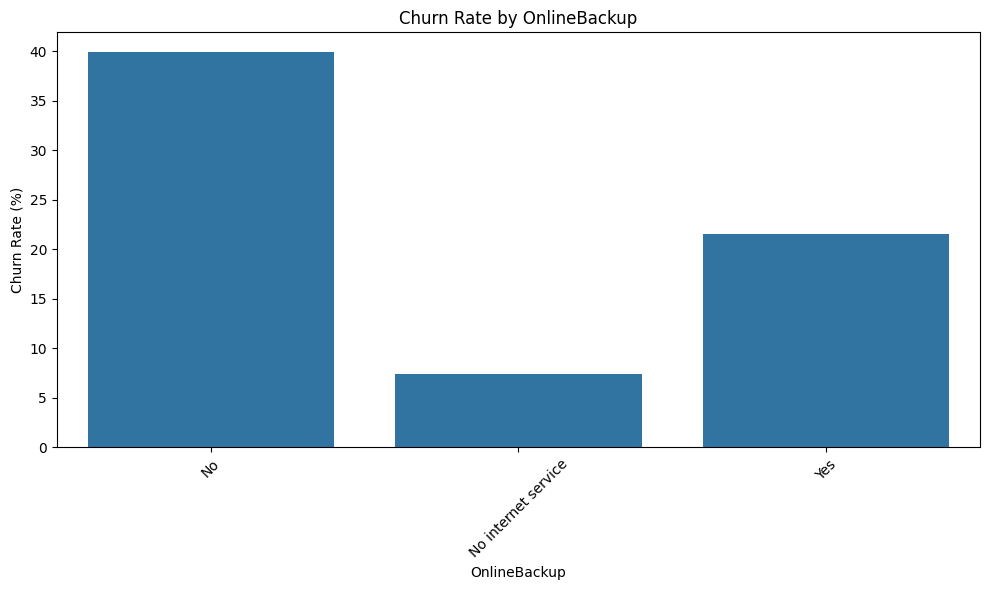

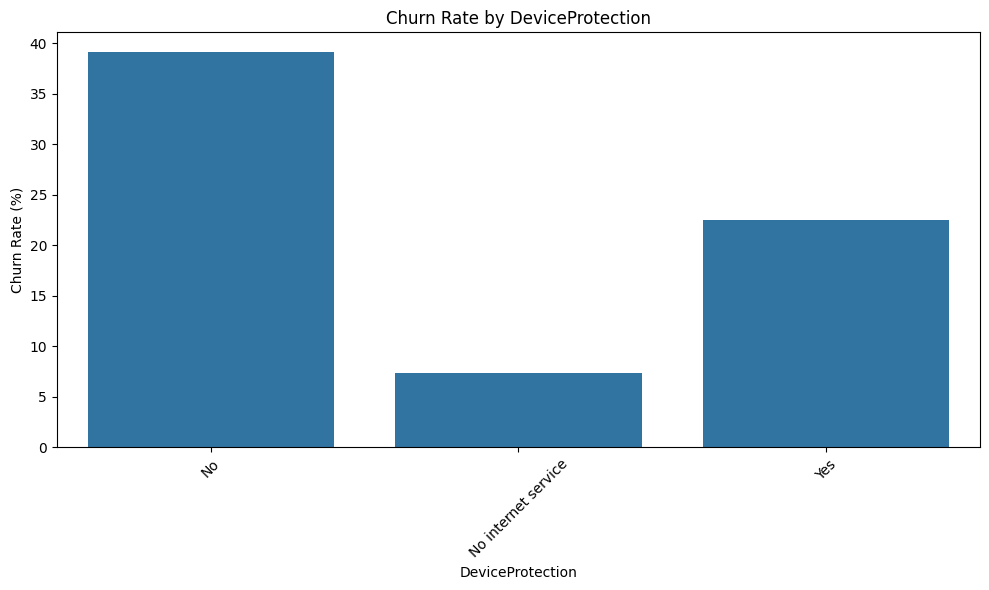

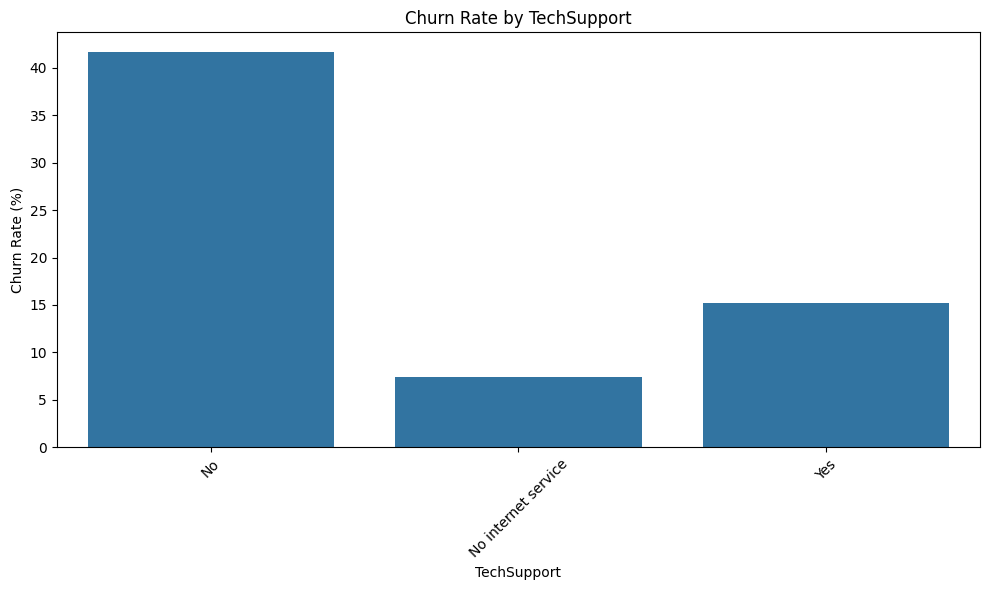

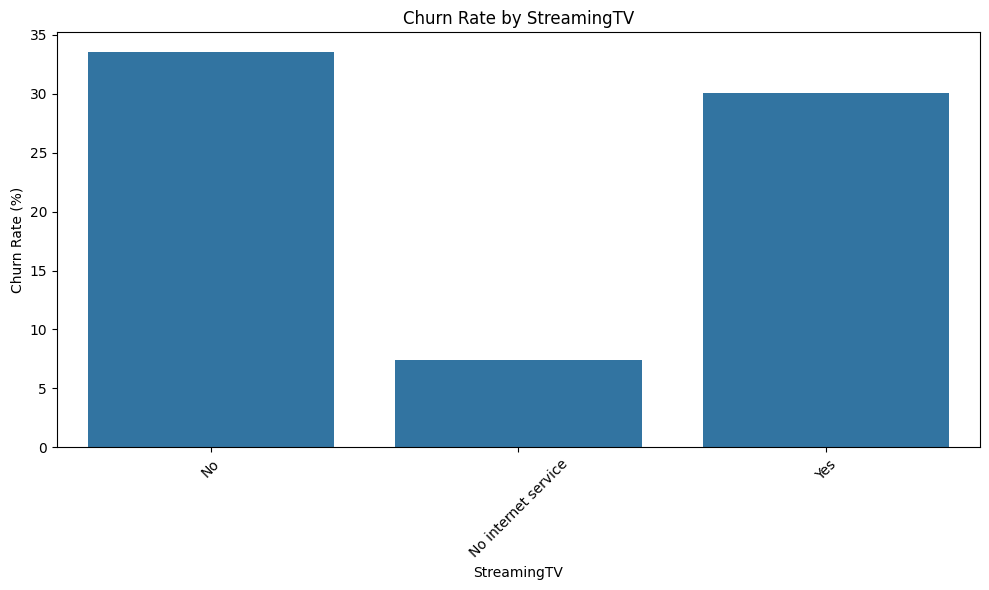

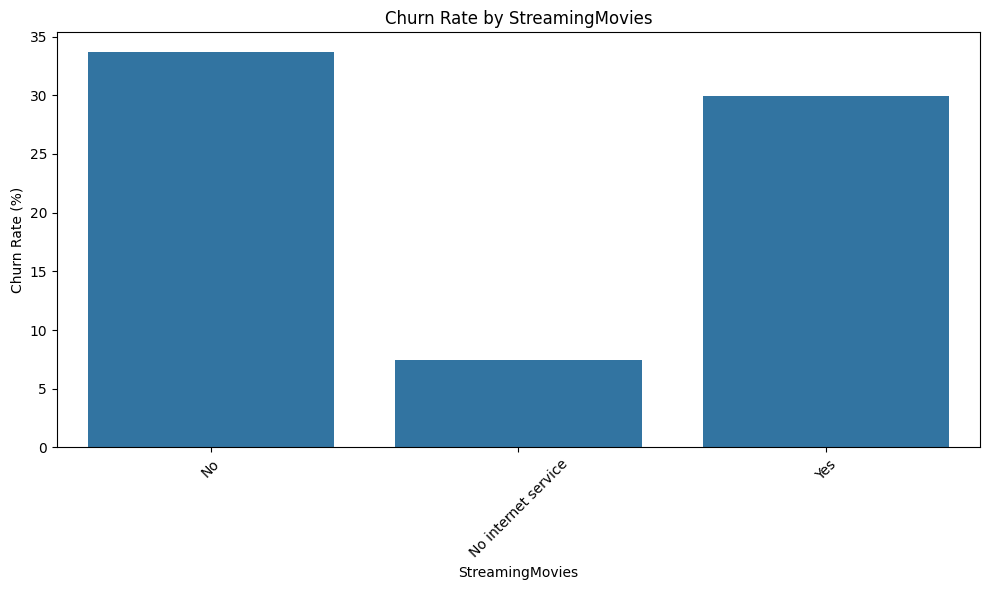

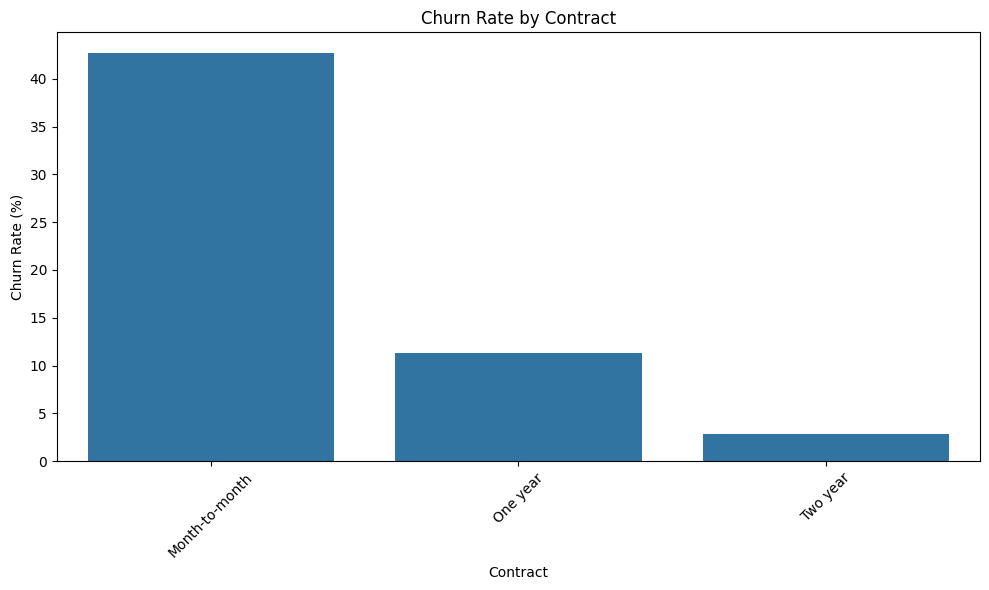

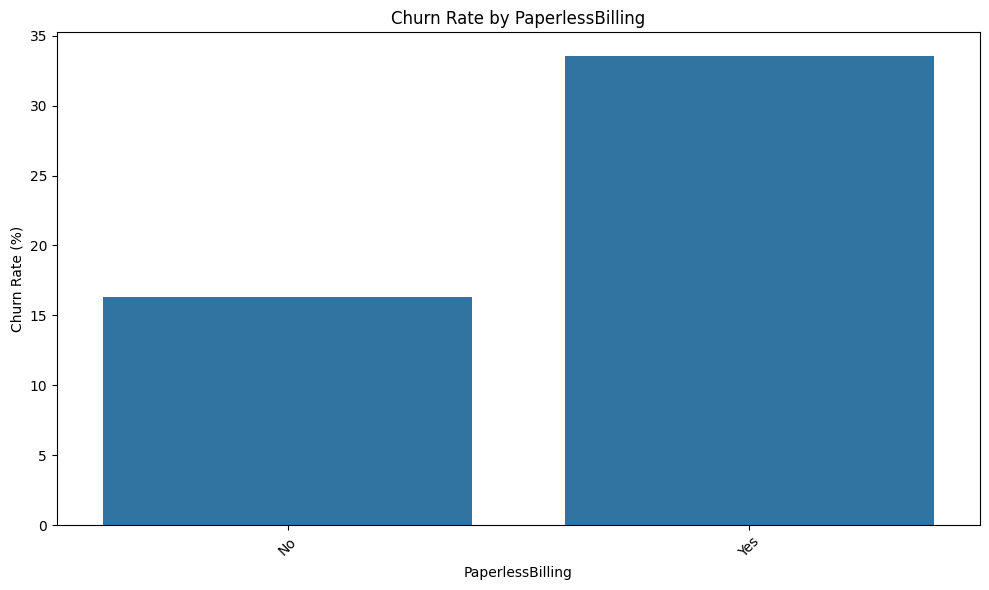

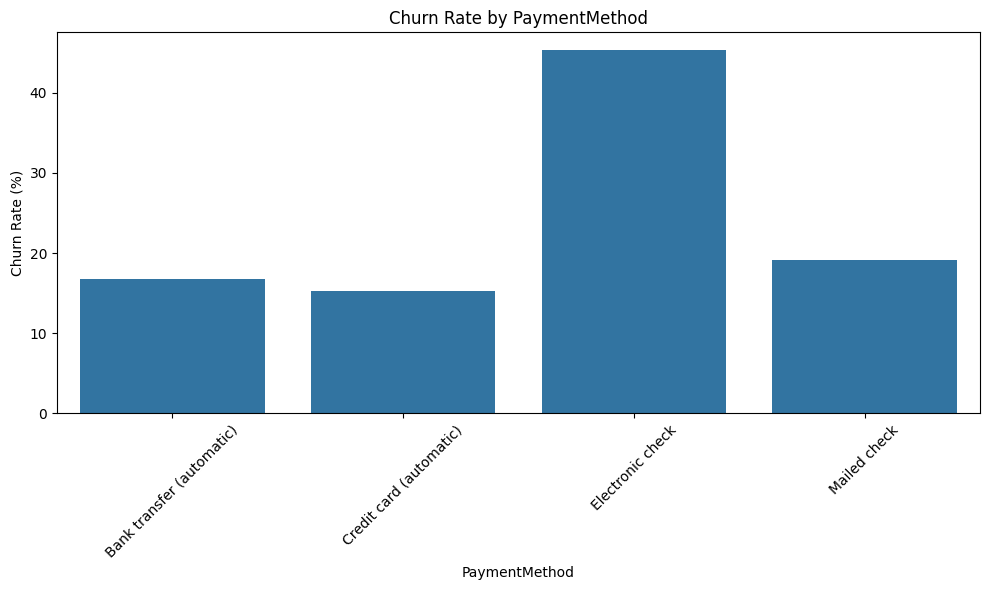

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

for cols, churn_rates_series in churn_rates.items():
  plt.figure(figsize=(10, 6))
  sns.barplot(x=churn_rates_series.index, y=churn_rates_series.values)
  plt.title(f'Churn Rate by {cols}')
  plt.xlabel(cols)
  plt.ylabel('Churn Rate (%)')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

In [10]:
#Based on the above data, dropping gender, phoneservice, multiple lines as they don't have significant impact on Churn
df = df.drop(['gender', 'PhoneService', 'MultipleLines'], axis=1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   InternetService   7043 non-null   object 
 6   OnlineSecurity    7043 non-null   object 
 7   OnlineBackup      7043 non-null   object 
 8   DeviceProtection  7043 non-null   object 
 9   TechSupport       7043 non-null   object 
 10  StreamingTV       7043 non-null   object 
 11  StreamingMovies   7043 non-null   object 
 12  Contract          7043 non-null   object 
 13  PaperlessBilling  7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      7043 non-null   float64


### Correlation by Heatmap

Now that we have seen categorical features, we now look at corelation by numeric features

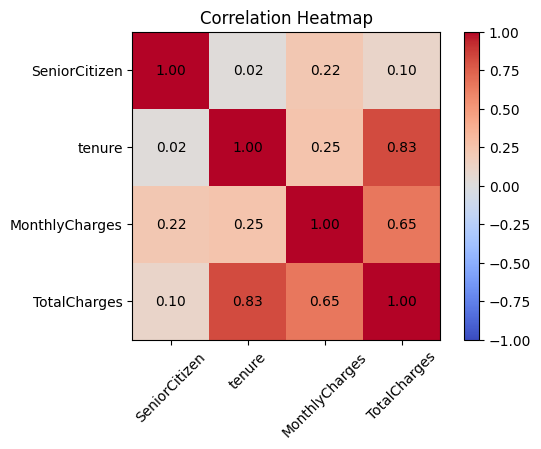

In [12]:
corr = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].corr()

plt.figure(figsize=(6,4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

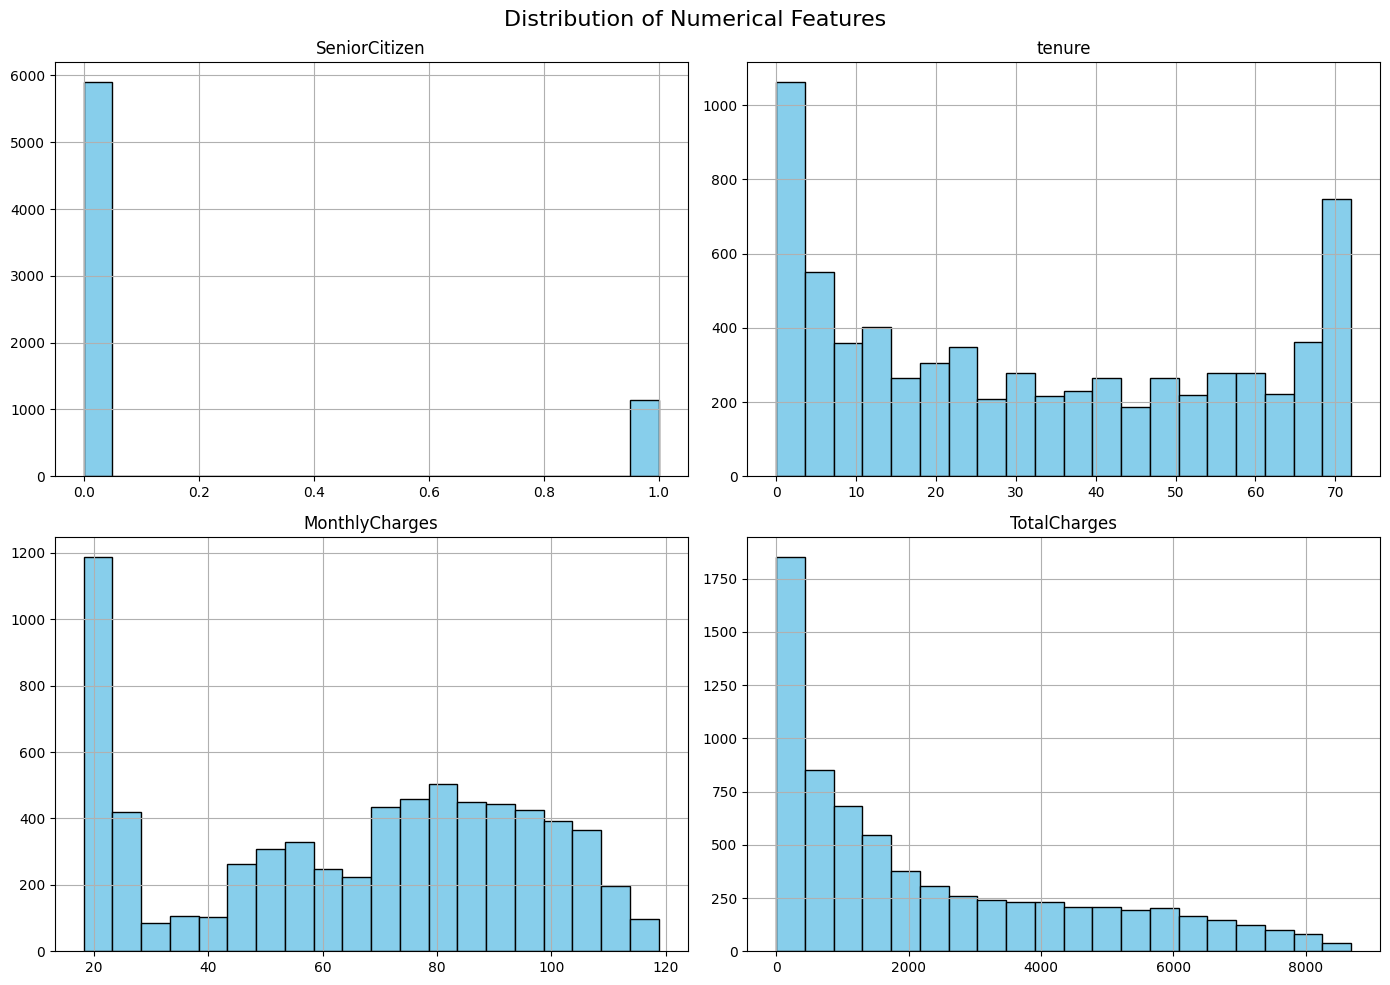

In [13]:
# 3. Distribution of Numerical Features
numerical_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_features].hist(bins=20, figsize=(14, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

### Outlier Detection

In [14]:
#Detecting outliers using IQR (No significant outliers identified)
outliers_data = {}

for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    num_outliers = len(outliers)

    outliers_data[feature] = {"num_outliers": num_outliers, "percentage": (num_outliers / len(df)) * 100}
    print(f"\nOutliers for {feature}:")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of outliers: {num_outliers}")
    print(f"Percentage of outliers: {(num_outliers / len(df)) * 100:.2f}%")


Outliers for SeniorCitizen:
Q1: 0.00
Q3: 0.00
IQR: 0.00
Lower Bound: 0.00
Upper Bound: 0.00
Number of outliers: 1142
Percentage of outliers: 16.21%

Outliers for tenure:
Q1: 9.00
Q3: 55.00
IQR: 46.00
Lower Bound: -60.00
Upper Bound: 124.00
Number of outliers: 0
Percentage of outliers: 0.00%

Outliers for MonthlyCharges:
Q1: 35.50
Q3: 89.85
IQR: 54.35
Lower Bound: -46.02
Upper Bound: 171.38
Number of outliers: 0
Percentage of outliers: 0.00%

Outliers for TotalCharges:
Q1: 398.55
Q3: 3786.60
IQR: 3388.05
Lower Bound: -4683.52
Upper Bound: 8868.67
Number of outliers: 0
Percentage of outliers: 0.00%


## Summary:

### Data Analysis Key Findings

*   **Contract Type:** Customers on Month-to-month contracts exhibit a significantly higher churn rate.
*   **Internet Service:** Fiber optic internet service is associated with a high churn rate of 41.89%, higher than the other two attributes.
*   **Payment Method:** Electronic check has the highest corelation to churn
*   **Ancillary Services:** Customers without 'OnlineSecurity' or 'TechSupport' services show higher churn rates, at 41.77% and 41.64%.
*   **Family Status:** Customers without a partner (32.96% churn) or dependents (31.28% churn) tend to churn more often than those with them.
*   **Tenure:** Churned customers generally have shorter tenures, while non-churned customers have longer tenures.
*   **MonthlyCharges:** Customers with higher monthly charges churn more.
*   **TotalCharges:** Churned customers tend to have lower total charges.
*   **Gender:** Gender does not have much impact on the churn

### Outliers

*   'TotalCharges','tenure' and'MonthlyCharges' has 0 outliers
*   'Senior Citizens' has outliers, but on further inspection (not seen here) removing the outliers reduced accuracy score slightly. The reduction in accuracy helped me not remove any outliers from senior citizens

### Initial Insights

*   **Targeted Retention Programs:** Focus on deploying offers to customers with 'Month-to-month' contracts, 'Fiber optic' internet service, and those paying via 'Electronic check'.

*   **Value-Add Service Promotion:** Educate customers on advantages of 'OnlineSecurity' and 'TechSupport' to customers without these services

## One-Hot Encoding of Categorical Features

Category variables are converted into a new column, and converted to 1 or 0 to represent the category in that particular column

In [15]:
#One-hot Endcoding
categorical_cols_encode = [col for col in df.select_dtypes(include='object').columns if col not in ['customerID', 'Churn']]
df_encoded = pd.get_dummies(df, columns=categorical_cols_encode, drop_first=True)

In [16]:
df_encoded.shape

(7043, 28)

In [17]:
df_encoded.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,No,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,0,34,56.95,1889.50,No,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,0,2,53.85,108.15,Yes,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,0,45,42.30,1840.75,No,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,0,2,70.70,151.65,Yes,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [18]:
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

In [19]:
#apply standard scalar to the encoded dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encoded_scaled = df_encoded.copy()
df_encoded_scaled[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(df_encoded_scaled[['tenure', 'MonthlyCharges', 'TotalCharges']])
df_encoded_scaled.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,-1.277445,-1.160323,-0.992611,0,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,0,0.066327,-0.259629,-0.172165,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,0,-1.236724,-0.362660,-0.958066,1,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,0,0.514251,-0.746535,-0.193672,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,0,-1.236724,0.197365,-0.938874,1,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [20]:
# split test train dataset and apply baseline model
from sklearn.model_selection import train_test_split
x = df_encoded_scaled.drop(['Churn', 'customerID'], axis=1)
y = df_encoded_scaled['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((5634, 26), (1409, 26))

In [21]:
#Build Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

df_log = LogisticRegression()
df_log.fit(x_train, y_train)

LogisticRegression()

In [22]:
#Build Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
import time
start_time = time.time()
df_log_pred = df_log.predict(x_test)
log_acc_test = accuracy_score(y_test, df_log_pred)
log_acc_train = accuracy_score(y_train, df_log.predict(x_train))
log_precision = precision_score(y_test, df_log_pred)
log_recall = recall_score(y_test, df_log_pred)
log_f1 = f1_score(y_test, df_log_pred)
log_train_time = time.time() - start_time

print(f"Logistic Regression Model")
print(f"Train Time of Logistic Model: {log_train_time:.1f} seconds")
print(f"Test Accuracy Score of Logistic Model: {log_acc_test:.2f}")
print(f"Train Accuracy Score of Logistic Model: {log_acc_train:.2f}")
print(f"Precision Score of Logistic Model: {log_precision:.2f}")
print(f"F1 Score of Logistic Model: {log_f1:.2f}")
print(f"Recall Score of Logistic Model: {log_recall:.2f}")

Logistic Regression Model
Train Time of Logistic Model: 0.1 seconds
Test Accuracy Score of Logistic Model: 0.82
Train Accuracy Score of Logistic Model: 0.80
Precision Score of Logistic Model: 0.69
F1 Score of Logistic Model: 0.64
Recall Score of Logistic Model: 0.60


Now we got the model to an accuracy of 0.82. We have to now compare to multiple models to understand which is the fastest and the most accurate of models

In [23]:
#knn classifier
from sklearn.neighbors import KNeighborsClassifier
start_time = time.time()
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
knn_pred = knn.predict(x_test)
knn_acc_test = accuracy_score(y_test, knn_pred)
knn_acc_train = accuracy_score(y_train, knn.predict(x_train))
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test,knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
end_time = time.time()
knn_train_time = time.time() - start_time

print(f"KNN Classifier")
print(f"Train Time of KNN Model: {knn_train_time:.1f} seconds")
print(f"Test Accuracy Score of KNN Model: {knn_acc_test:.2f}")
print(f"Train Accuracy Score of KNN Model: {knn_acc_train:.2f}")
print(f"Precision Score of KNN Model: {knn_precision:.2f}")
print(f"F1 Score of KNN Model: {knn_f1:.2f}")
print(f"Recall Score of KNN Model: {knn_recall:.2f}")

KNN Classifier
Train Time of KNN Model: 0.6 seconds
Test Accuracy Score of KNN Model: 0.77
Train Accuracy Score of KNN Model: 0.84
Precision Score of KNN Model: 0.57
F1 Score of KNN Model: 0.54
Recall Score of KNN Model: 0.51


In [24]:
#Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

start_time = time.time()
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)
dt_acc_test = accuracy_score(y_test, dt_pred)
dt_acc_train = accuracy_score(y_train, dt.predict(x_train))
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test,dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
end_time = time.time()
dt_train_time = end_time - start_time

print(f"Decision Tree Classifier")
print(f"Train Time of Decision Tree Model: {dt_train_time:.1f} seconds")
print(f"Test Accuracy Score of Decision Tree Model: {dt_acc_train:.2f}")
print(f"Train Accuracy Score of Decision Tree Model: {dt_acc_test: .2f}")
print(f"Precision Score of Decision Tree Model: {dt_precision:.2f}")
print(f"F1 Score of Decision Tree Model: {dt_f1:.2f}")
print(f"Recall Score of Decision Tree Model: {dt_recall:.2f}")

Decision Tree Classifier
Train Time of Decision Tree Model: 0.1 seconds
Test Accuracy Score of Decision Tree Model: 1.00
Train Accuracy Score of Decision Tree Model:  0.71
Precision Score of Decision Tree Model: 0.45
F1 Score of Decision Tree Model: 0.46
Recall Score of Decision Tree Model: 0.47


In [25]:
#SVM Model
from sklearn.svm import SVC

start_time = time.time()
svm = SVC()
svm.fit(x_train, y_train)
svm_pred = svm.predict(x_test)
svm_acc_test = accuracy_score(y_test, svm_pred)
svm_acc_train = accuracy_score(y_train, svm.predict(x_train))
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test,svm_pred)
svm_f1 = f1_score(y_test, svm_pred)
end_time = time.time()
svm_train_time = end_time - start_time

print(f"SVM Classifier")
print(f"Train Time of SVM Model: {svm_train_time:.2f} seconds")
print(f"Test Accuracy Score of SVM Model: {svm_acc_test:.2f}")
print(f"Train Accuracy Score of SVM Model: {svm_acc_train:.2f}")
print(f"Precision Score of SVM Model: {svm_precision:.2f}")
print(f"F1 Score of SVM Model: {svm_f1:.2f}")
print(f"Recall Score of SVM Model : {svm_recall:.2f}")

SVM Classifier
Train Time of SVM Model: 2.92 seconds
Test Accuracy Score of SVM Model: 0.81
Train Accuracy Score of SVM Model: 0.81
Precision Score of SVM Model: 0.69
F1 Score of SVM Model: 0.58
Recall Score of SVM Model : 0.51


In [26]:
# model performance data in a tabular format
all_model_data = {'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Train Time (s)': [log_train_time,knn_train_time,dt_train_time,svm_train_time],
    'Train Accuracy': [log_acc_train,knn_acc_train,dt_acc_train,svm_acc_train],
    'Test Accuracy': [log_acc_test,knn_acc_test,dt_acc_test,svm_acc_test],
     'f1 Score': [log_f1,knn_f1,dt_f1,svm_f1],
     'Precision Score':[log_precision,knn_precision,dt_precision,svm_precision],
      'Recall Score':[log_recall,knn_recall,dt_recall,svm_recall]}

all_mod_comp_df = pd.DataFrame(all_model_data)

display(all_mod_comp_df)

,Model,Train Time (s),Train Accuracy,Test Accuracy,f1 Score,Precision Score,Recall Score
0,Logistic Regression,0.057322,0.798012,0.821859,0.638849,0.689441,0.595174
1,KNN,0.571852,0.838126,0.770050,0.539773,0.574018,0.509383
2,Decision Tree,0.080185,0.998048,0.707594,0.459318,0.449871,0.469169
3,SVM,2.922221,0.809017,0.808375,0.584615,0.685921,0.509383


Above we see the models having accuracy and all scores without the tuning. Now we further tune the models with grid search and see how the final accuracy scores would look

In [27]:
#Hyper parameter tuning for logistic regression using GridsearchCV
from sklearn.model_selection import GridSearchCV

start_time = time.time()
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_log = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid_log.fit(x_train, y_train)
grid_log_model = grid_log.best_estimator_
grid_log_pred_test = grid_log_model.predict(x_test)
grid_log_acc_test = accuracy_score(y_test, grid_log_pred_test)
grid_log_pred_train = grid_log_model.predict(x_train)
grid_log_acc_train = accuracy_score(y_train, grid_log_pred_train)
grid_log_precision = precision_score(y_test, grid_log_pred_test)
grid_log_recall = recall_score(y_test,grid_log_pred_test)
grid_log_f1 = f1_score(y_test, grid_log_pred_test)
end_time = time.time()
grid_log_train_time = end_time - start_time



print(f"Tuned Logistic Regression Model Estimator: {grid_log_model}")
print(f"Train Time of Tuned Logistic Model: {grid_log_train_time:.1f} seconds")
print(f"Test Accuracy Score Tuned Logistic Model: {grid_log_acc_test:.2f}")
print(f"Train Accuracy Score Tuned Logistic Model: {grid_log_acc_train:.2f}")
print(f"Precision Score Tuned Logistic Model: {grid_log_precision:.2f}")
print(f"F1 Score Tuned Logistic Model: {grid_log_f1:.2f}")
print(f"Recall Score Tuned Logistic Model: {grid_log_recall:.2f}")

Tuned Logistic Regression Model Estimator: LogisticRegression(C=0.1)
Train Time of Tuned Logistic Model: 2.7 seconds
Test Accuracy Score Tuned Logistic Model: 0.82
Train Accuracy Score Tuned Logistic Model: 0.80
Precision Score Tuned Logistic Model: 0.70
F1 Score Tuned Logistic Model: 0.64
Recall Score Tuned Logistic Model: 0.59


In [28]:
# Hyperparameter tuning for KNN

start_time = time.time()
param_grid = {'n_neighbors': [1,3,5,7,9,11,13,15,17]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_knn.fit(x_train, y_train)
grid_knn_model = grid_knn.best_estimator_
grid_knn_pred_test = grid_knn_model.predict(x_test)
grid_knn_acc_test = accuracy_score(y_test, grid_knn_pred_test)
grid_knn_pred_train = grid_knn_model.predict(x_train)
grid_knn_acc_train = accuracy_score(y_train, grid_knn_pred_train)
grid_knn_precision = precision_score(y_test, grid_knn_pred_test)
grid_knn_f1 = f1_score(y_test, grid_knn_pred_test)
grid_knn_recall = recall_score(y_test,grid_knn_pred_test)
end_time = time.time()
grid_knn_train_time = end_time - start_time

print(f"Grid n KNN Model: {grid_knn_model}")
print(f"Train Time of Tuned KNN Model: {grid_knn_train_time:.1f} seconds")
print(f"Test Accuracy Score for tuned KNN Model: {grid_knn_acc_test:.2f}")
print(f"Train Accuracy Score for tuned KNN Model: {grid_knn_acc_train:.2f}")
print(f"Precision Score for tuned KNN Model: {grid_knn_precision:.2f}")
print(f"F1 Score for tuned KNN Model: {grid_knn_f1:.2f}")
print(f"Recall Score for tuned KNN Model: {grid_knn_recall:.2f}")

Grid n KNN Model: KNeighborsClassifier(n_neighbors=17)
Train Time of Tuned KNN Model: 2.3 seconds
Test Accuracy Score for tuned KNN Model: 0.80
Train Accuracy Score for tuned KNN Model: 0.81
Precision Score for tuned KNN Model: 0.65
F1 Score for tuned KNN Model: 0.61
Recall Score for tuned KNN Model: 0.57


In [29]:
#Hyperparameter Tuning for Decision Tree

start_time = time.time()
param_grid = {'max_depth': [None,1,3,5,7,9,10,15,20,25,30,35,40,45,50]}
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_dt.fit(x_train, y_train)
grid_dt_model = grid_dt.best_estimator_
grid_dt_pred_test = grid_dt_model.predict(x_test)
grid_dt_acc_test = accuracy_score(y_test, grid_dt_pred_test)
grid_dt_pred_train = grid_dt_model.predict(x_train)
grid_dt_acc_train = accuracy_score(y_train, grid_dt_pred_train)
grid_dt_precision = precision_score(y_test, grid_dt_pred_test)
grid_dt_f1 = f1_score(y_test, grid_dt_pred_test)
grid_dt_recall = recall_score(y_test,grid_dt_pred_test)
end_time = time.time()
grid_dt_train_time = end_time - start_time

print(f"Max Depth Decision Tree Model:{grid_dt_model}")
print(f"Train Time of Tuned Decision Tree Model: {grid_dt_train_time:.1f} seconds")
print(f"Test Accuracy Score of Tuned Decision Tree Model: {grid_dt_acc_test:.2f}")
print(f"Train Accuracy Score of Tuned Decision Tree Model: {grid_dt_acc_train:.2f}")
print(f"Precision Score of Tuned Decision Tree Model: {grid_dt_precision:.2f}")
print(f"F1 Score of Tuned Decision Tree Model: {grid_dt_f1:.2f}")
print(f"Recall Score of Tuned Decision Tree Model: {grid_dt_recall:.2f}")

Max Depth Decision Tree Model:DecisionTreeClassifier(max_depth=5)
Train Time of Tuned Decision Tree Model: 2.9 seconds
Test Accuracy Score of Tuned Decision Tree Model: 0.80
Train Accuracy Score of Tuned Decision Tree Model: 0.80
Precision Score of Tuned Decision Tree Model: 0.68
F1 Score of Tuned Decision Tree Model: 0.54
Recall Score of Tuned Decision Tree Model: 0.45


In [30]:
#Hyperparameter Tuning for SVM

start_time = time.time()
param_grid = {'C': [0.001, 0.01,1,10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(), param_grid, cv=5)
grid_svm.fit(x_train, y_train)
grid_svm_model = grid_svm.best_estimator_
grid_svm_pred_test = grid_svm_model.predict(x_test)
grid_svm_acc_test = accuracy_score(y_test, grid_svm_pred_test)
grid_svm_pred_train = grid_svm_model.predict(x_train)
grid_svm_acc_train = accuracy_score(y_train, grid_svm_pred_train)
grid_svm_precision = precision_score(y_test, grid_svm_pred_test)
grid_svm_f1 = f1_score(y_test, grid_svm_pred_test)
grid_svm_recall = recall_score(y_test,grid_svm_pred_test)
end_time = time.time()
grid_svm_train_time = end_time - start_time

print(f"Tuned SVM Model: {grid_svm_model}")
print(f"Train Time of Tuned SVM Model: {grid_svm_train_time:.1f} seconds")
print(f"Test Accuracy Score of Tuned SVM Model: {grid_svm_acc_test:.2f}")
print(f"Train Accuracy Score of Tuned SVM Model: {grid_svm_acc_train:.2f}")
print(f"Precision Score of Tuned SVM Model: {grid_svm_precision:.2f}")
print(f"F1 Score of Tuned SVM Model: {grid_svm_f1:.2f}")
print(f"Recall Score of Tuned SVM Model: {grid_svm_recall:.2f}")

Tuned SVM Model: SVC(C=0.01, kernel='linear')
Train Time of Tuned SVM Model: 42.8 seconds
Test Accuracy Score of Tuned SVM Model: 0.82
Train Accuracy Score of Tuned SVM Model: 0.79
Precision Score of Tuned SVM Model: 0.70
F1 Score of Tuned SVM Model: 0.63
Recall Score of Tuned SVM Model: 0.58


In [31]:
all_model_tuned_data = {'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM',
'Logitic Regression Tuned','KNN_Tuned','Decision Tree Tuned','SVM Tuned'],
    'Train Time (s)': [log_train_time,knn_train_time,dt_train_time,svm_train_time,
                       grid_log_train_time,grid_knn_train_time,grid_dt_train_time,
                       grid_svm_train_time],
    'Train Accuracy': [log_acc_train,knn_acc_train,dt_acc_train,svm_acc_train,
                       grid_log_acc_train,grid_knn_acc_train,grid_dt_acc_train,
                       grid_svm_acc_train],
    'Test Accuracy': [log_acc_test,knn_acc_test,dt_acc_test,svm_acc_test,
                      grid_log_acc_test,grid_knn_acc_test,grid_dt_acc_test,
                      grid_svm_acc_test],
     'f1 Score': [log_f1,knn_f1,dt_f1,svm_f1,grid_log_f1,grid_knn_f1,grid_dt_f1,grid_svm_f1],
     'Precision Score':[log_precision,knn_precision,dt_precision,svm_precision,grid_log_precision,
                        grid_knn_precision,grid_dt_precision,grid_svm_precision],
     'Recall Score':[log_recall,knn_recall,dt_recall,svm_recall,
                     grid_log_recall, grid_knn_recall, grid_dt_recall, grid_svm_recall]
                        }

all_mod_tuned_comp_df = pd.DataFrame(all_model_tuned_data)

display(all_mod_tuned_comp_df)

,Model,Train Time (s),Train Accuracy,Test Accuracy,f1 Score,Precision Score,Recall Score
0,Logistic Regression,0.057322,0.798012,0.821859,0.638849,0.689441,0.595174
1,KNN,0.571852,0.838126,0.770050,0.539773,0.574018,0.509383
2,Decision Tree,0.080185,0.998048,0.707594,0.459318,0.449871,0.469169
3,SVM,2.922221,0.809017,0.808375,0.584615,0.685921,0.509383
4,Logitic Regression Tuned,2.748055,0.799077,0.824698,0.639416,0.701923,0.587131
5,KNN_Tuned,2.280088,0.808662,0.804826,0.608819,0.648485,0.573727
6,Decision Tree Tuned,2.860652,0.797657,0.799148,0.544283,0.681452,0.453083
7,SVM Tuned,42.840742,0.794462,0.822569,0.633431,0.699029,0.579088


### Model Performance so far
*   **Logistic Regression (Tuned)**: This model maintains a strong balance between accuracy and interpretability. Its performance is robust and training time is reasonable.
*   **KNN (Tuned):** KNN shows decent performance, especially in recall, but is slightly lower in overall accuracy compared to Logistic Regression.
*    **Decision Tree (Tuned):** While having a good precision, its recall and F1 score are lower, indicating it misses more actual churners. It's the fastest to train among the tuned models.
*    **SVM (Tuned):** SVM provides competitive precision but has a much higher training time

### Best Performing Model(s)
Based on the balanced performance across accuracy, precision, and F1-score, and considering the training time:
*   The **Tuned Logistic Regression Model** appears to be the most practical choice. It offers the highest test accuracy (0.82) and a good balance across precision (0.70) and F1-score (0.63) with a relatively quick training time. Its interpretability is also a significant advantage for business insights.
*   The **Tuned SVM Model** shows similar accuracy and precision but comes with a significantly higher training cost, making Logistic Regression more favorable for a production environment where model updates might be frequent.

### Further Improvize
Since this is a Churn dataset and often comes with a little bit imbalanced data set of fewer churners than non churners, I am going to try to implement Smote to see if the accuracy improves







Apply SMOTE to the training and test data to handle class imbalance.

In [32]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
x_smote, y_smote = sm.fit_resample(x_train, y_train)


print("Original dataset shape (x_train):", {x_train.shape})
print("Original dataset shape (y_train):", {y_train.shape})
print("Resampled dataset shape (x_smote):", {x_smote.shape})
print("Resampled dataset shape (y_smote):", {y_smote.shape})



Original dataset shape (x_train): {(5634, 26)}
Original dataset shape (y_train): {(5634,)}
Resampled dataset shape (x_smote): {(8276, 26)}
Resampled dataset shape (y_smote): {(8276,)}


In [33]:
#SMOTE Log Regression
start_time = time.time()
df_log_smote = LogisticRegression()
df_log_smote.fit(x_smote, y_smote)
df_log_pred_smote = df_log_smote.predict(x_test)
log_acc_test_smote = accuracy_score(y_test, df_log_pred_smote)
log_acc_train_smote = accuracy_score(y_smote, df_log_smote.predict(x_smote))
log_precision_smote = precision_score(y_test, df_log_pred_smote)
log_recall_smote = recall_score(y_test, df_log_pred_smote)
log_f1_smote = f1_score(y_test, df_log_pred_smote)
log_train_time_smote = time.time() - start_time

print(f"Logistic Regression Model with SMOTE")
print(f"Train Time of Logistic Model with SMOTE: {log_train_time_smote:.3f} seconds")
print(f"Test Accuracy Score of Logistic Model with SMOTE: {log_acc_test_smote:.2f}")
print(f"Train Accuracy Score of Logistic Model with SMOTE: {log_acc_train_smote:.2f}")
print(f"Precision Score of Logistic Model with SMOTE: {log_precision_smote:.2f}")
print(f"F1 Score of Logistic Model with SMOTE: {log_f1_smote:.2f}")
print(f"Recall Score of Logistic Model with SMOTE: {log_recall_smote:.2f}")

Logistic Regression Model with SMOTE
Train Time of Logistic Model with SMOTE: 0.059 seconds
Test Accuracy Score of Logistic Model with SMOTE: 0.74
Train Accuracy Score of Logistic Model with SMOTE: 0.78
Precision Score of Logistic Model with SMOTE: 0.51
F1 Score of Logistic Model with SMOTE: 0.62
Recall Score of Logistic Model with SMOTE: 0.79


In [34]:
#KNN SMOTE

start_time = time.time()
knn_smote = KNeighborsClassifier()
knn_smote.fit(x_smote, y_smote)
knn_pred_smote = knn_smote.predict(x_test)
knn_acc_test_smote = accuracy_score(y_test, knn_pred_smote)
knn_acc_train_smote = accuracy_score(y_smote, knn_smote.predict(x_smote))
knn_precision_smote = precision_score(y_test, knn_pred_smote)
knn_recall_smote = recall_score(y_test, knn_pred_smote)
knn_f1_smote = f1_score(y_test, knn_pred_smote)
knn_train_time_smote = time.time() - start_time

print(f"KNN Classifier with SMOTE")
print(f"Train Time of KNN Model with SMOTE: {knn_train_time_smote:.3f} seconds")
print(f"Test Accuracy Score of KNN Model with SMOTE: {knn_acc_test_smote:.2f}")
print(f"Train Accuracy Score of KNN Model with SMOTE: {knn_acc_train_smote:.2f}")
print(f"Precision Score of KNN Model with SMOTE: {knn_precision_smote:.2f}")
print(f"F1 Score of KNN Model with SMOTE: {knn_f1_smote:.2f}")
print(f"Recall Score of KNN Model with SMOTE: {knn_recall_smote:.2f}")

KNN Classifier with SMOTE
Train Time of KNN Model with SMOTE: 0.559 seconds
Test Accuracy Score of KNN Model with SMOTE: 0.71
Train Accuracy Score of KNN Model with SMOTE: 0.86
Precision Score of KNN Model with SMOTE: 0.47
F1 Score of KNN Model with SMOTE: 0.57
Recall Score of KNN Model with SMOTE: 0.73


In [35]:
#Decision Tree SMOTE

start_time = time.time()
dt_smote = DecisionTreeClassifier()
dt_smote.fit(x_smote, y_smote)
dt_pred_smote = dt_smote.predict(x_test)
dt_acc_test_smote = accuracy_score(y_test, dt_pred_smote)
dt_acc_train_smote = accuracy_score(y_smote, dt_smote.predict(x_smote))
dt_precision_smote = precision_score(y_test, dt_pred_smote)
dt_recall_smote = recall_score(y_test, dt_pred_smote)
dt_f1_smote = f1_score(y_test, dt_pred_smote)
dt_train_time_smote = time.time() - start_time

print(f"Decision Tree Classifier with SMOTE")
print(f"Train Time of Decision Tree Model with SMOTE: {dt_train_time_smote:.3f} seconds")
print(f"Test Accuracy Score of Decision Tree Model with SMOTE: {dt_acc_test_smote:.2f}")
print(f"Train Accuracy Score of Decision Tree Model with SMOTE: {dt_acc_train_smote:.2f}")
print(f"Precision Score of Decision Tree Model with SMOTE: {dt_precision_smote:.2f}")
print(f"F1 Score of Decision Tree Model with SMOTE: {dt_f1_smote:.2f}")
print(f"Recall Score of Decision Tree Model with SMOTE: {dt_recall_smote:.2f}")


Decision Tree Classifier with SMOTE
Train Time of Decision Tree Model with SMOTE: 0.093 seconds
Test Accuracy Score of Decision Tree Model with SMOTE: 0.73
Train Accuracy Score of Decision Tree Model with SMOTE: 1.00
Precision Score of Decision Tree Model with SMOTE: 0.48
F1 Score of Decision Tree Model with SMOTE: 0.52
Recall Score of Decision Tree Model with SMOTE: 0.57


In [36]:
#SVM SMOTE
start_time = time.time()
svm_smote = SVC()
svm_smote.fit(x_smote, y_smote)
svm_pred_smote = svm_smote.predict(x_test)
svm_acc_test_smote = accuracy_score(y_test, svm_pred_smote)
svm_acc_train_smote = accuracy_score(y_smote, svm_smote.predict(x_smote))
svm_precision_smote = precision_score(y_test, svm_pred_smote)
svm_recall_smote = recall_score(y_test, svm_pred_smote)
svm_f1_smote = f1_score(y_test, svm_pred_smote)
svm_train_time_smote = time.time() - start_time

print(f"SVM Classifier with SMOTE")
print(f"Train Time of SVM Model with SMOTE: {svm_train_time_smote:.3f} seconds")
print(f"Test Accuracy Score of SVM Model with SMOTE: {svm_acc_test_smote:.2f}")
print(f"Train Accuracy Score of SVM Model with SMOTE: {svm_acc_train_smote:.2f}")
print(f"Precision Score of SVM Model with SMOTE: {svm_precision_smote:.2f}")
print(f"F1 Score of SVM Model with SMOTE: {svm_f1_smote:.2f}")
print(f"Recall Score of SVM Model with SMOTE: {svm_recall_smote:.2f}")

SVM Classifier with SMOTE
Train Time of SVM Model with SMOTE: 8.931 seconds
Test Accuracy Score of SVM Model with SMOTE: 0.76
Train Accuracy Score of SVM Model with SMOTE: 0.81
Precision Score of SVM Model with SMOTE: 0.53
F1 Score of SVM Model with SMOTE: 0.63
Recall Score of SVM Model with SMOTE: 0.80


In [37]:
#Consolidated data in table
all_model_data_smote = {
    'Model': ['Logistic Regression SMOTE', 'KNN SMOTE', 'Decision Tree SMOTE', 'SVM SMOTE'],
    'Train Time (s)': [log_train_time_smote, knn_train_time_smote, dt_train_time_smote, svm_train_time_smote],
    'Train Accuracy': [log_acc_train_smote, knn_acc_train_smote, dt_acc_train_smote, svm_acc_train_smote],
    'Test Accuracy': [log_acc_test_smote, knn_acc_test_smote, dt_acc_test_smote, svm_acc_test_smote],
    'f1 Score': [log_f1_smote, knn_f1_smote, dt_f1_smote, svm_f1_smote],
    'Precision Score': [log_precision_smote, knn_precision_smote, dt_precision_smote, svm_precision_smote],
    'Recall Score': [log_recall_smote, knn_recall_smote, dt_recall_smote, svm_recall_smote]
}

all_mod_comp_df_smote = pd.DataFrame(all_model_data_smote)
all_mod_comp_df = pd.concat([all_mod_comp_df, all_mod_comp_df_smote], ignore_index=True)

display(all_mod_comp_df)

,Model,Train Time (s),Train Accuracy,Test Accuracy,f1 Score,Precision Score,Recall Score
0,Logistic Regression,0.057322,0.798012,0.821859,0.638849,0.689441,0.595174
1,KNN,0.571852,0.838126,0.770050,0.539773,0.574018,0.509383
2,Decision Tree,0.080185,0.998048,0.707594,0.459318,0.449871,0.469169
3,SVM,2.922221,0.809017,0.808375,0.584615,0.685921,0.509383
4,Logistic Regression SMOTE,0.058636,0.775979,0.741661,0.616842,0.507799,0.785523
5,KNN SMOTE,0.558659,0.864065,0.711143,0.572029,0.470588,0.729223
6,Decision Tree SMOTE,0.093014,0.998671,0.725337,0.523985,0.484091,0.571046
7,SVM SMOTE,8.931393,0.806307,0.755855,0.633262,0.525664,0.796247


I am going to further evaluate the model by hyperparameter tuning using GridsearchCV on SMOTE data and guage the performance

In [38]:
#Logistic Regression
start_time = time.time()
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_log_smote = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid_log_smote.fit(x_smote, y_smote)
grid_log_smote_model = grid_log_smote.best_estimator_
grid_log_pred_test_smote = grid_log_smote_model.predict(x_test)
grid_log_acc_test_smote = accuracy_score(y_test, grid_log_pred_test_smote)
grid_log_pred_train_smote = grid_log_smote_model.predict(x_smote)
grid_log_acc_train_smote = accuracy_score(y_smote, grid_log_pred_train_smote)
grid_log_precision_smote = precision_score(y_test, grid_log_pred_test_smote)
grid_log_f1_smote = f1_score(y_test, grid_log_pred_test_smote)
grid_log_recall_smote = recall_score(y_test, grid_log_pred_test_smote)
end_time = time.time()
grid_log_train_time_smote = end_time - start_time

print(f"Tuned Logistic Regression Model with SMOTE Estimator: {grid_log_smote_model}")
print(f"Train Time of Tuned Logistic Model with SMOTE: {grid_log_train_time_smote:.1f} seconds")
print(f"Test Accuracy Score Tuned Logistic Model with SMOTE: {grid_log_acc_test_smote:.2f}")
print(f"Train Accuracy Score Tuned Logistic Model with SMOTE: {grid_log_acc_train_smote:.2f}")
print(f"Precision Score Tuned Logistic Model with SMOTE: {grid_log_precision_smote:.2f}")
print(f"F1 Score Tuned Logistic Model with SMOTE: {grid_log_f1_smote:.2f}")
print(f"Recall Score Tuned Logistic Model with SMOTE: {grid_log_recall_smote:.2f}")

Tuned Logistic Regression Model with SMOTE Estimator: LogisticRegression(C=10, max_iter=1000)
Train Time of Tuned Logistic Model with SMOTE: 2.3 seconds
Test Accuracy Score Tuned Logistic Model with SMOTE: 0.74
Train Accuracy Score Tuned Logistic Model with SMOTE: 0.78
Precision Score Tuned Logistic Model with SMOTE: 0.51
F1 Score Tuned Logistic Model with SMOTE: 0.62
Recall Score Tuned Logistic Model with SMOTE: 0.79


In [39]:
#KNN
start_time = time.time()
param_grid = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17]}
grid_knn_smote = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_knn_smote.fit(x_smote, y_smote)
grid_knn_smote_model = grid_knn_smote.best_estimator_
grid_knn_pred_test_smote = grid_knn_smote_model.predict(x_test)
grid_knn_acc_test_smote = accuracy_score(y_test, grid_knn_pred_test_smote)
grid_knn_pred_train_smote = grid_knn_smote_model.predict(x_smote)
grid_knn_acc_train_smote = accuracy_score(y_smote, grid_knn_pred_train_smote)
grid_knn_precision_smote = precision_score(y_test, grid_knn_pred_test_smote)
grid_knn_f1_smote = f1_score(y_test, grid_knn_pred_test_smote)
grid_knn_recall_smote = recall_score(y_test, grid_knn_pred_test_smote)
end_time = time.time()
grid_knn_train_time_smote = end_time - start_time

print(f"Tuned KNN Model with SMOTE Estimator: {grid_knn_smote_model}")
print(f"Train Time of Tuned KNN Model with SMOTE: {grid_knn_train_time_smote:.1f} seconds")
print(f"Test Accuracy Score Tuned KNN Model with SMOTE: {grid_knn_acc_test_smote:.2f}")
print(f"Train Accuracy Score Tuned KNN Model with SMOTE: {grid_knn_acc_train_smote:.2f}")
print(f"Precision Score Tuned KNN Model with SMOTE: {grid_knn_precision_smote:.2f}")
print(f"F1 Score Tuned KNN Model with SMOTE: {grid_knn_f1_smote:.2f}")
print(f"Recall Score Tuned KNN Model with SMOTE: {grid_knn_recall_smote:.2f}")

Tuned KNN Model with SMOTE Estimator: KNeighborsClassifier(n_neighbors=1)
Train Time of Tuned KNN Model with SMOTE: 4.3 seconds
Test Accuracy Score Tuned KNN Model with SMOTE: 0.71
Train Accuracy Score Tuned KNN Model with SMOTE: 1.00
Precision Score Tuned KNN Model with SMOTE: 0.45
F1 Score Tuned KNN Model with SMOTE: 0.51
Recall Score Tuned KNN Model with SMOTE: 0.57


In [40]:
#Decision Tree
start_time = time.time()
param_grid = {'max_depth': [None,1,3,5,7,9,10,15,20,25,30,35,40,45,50]}
grid_dt_smote = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_dt_smote.fit(x_smote, y_smote)
grid_dt_smote_model = grid_dt_smote.best_estimator_
grid_dt_pred_test_smote = grid_dt_smote_model.predict(x_test)
grid_dt_acc_test_smote = accuracy_score(y_test, grid_dt_pred_test_smote)
grid_dt_pred_train_smote = grid_dt_smote_model.predict(x_smote)
grid_dt_acc_train_smote = accuracy_score(y_smote, grid_dt_pred_train_smote)
grid_dt_precision_smote = precision_score(y_test, grid_dt_pred_test_smote)
grid_dt_f1_smote = f1_score(y_test, grid_dt_pred_test_smote)
grid_dt_recall_smote = recall_score(y_test, grid_dt_pred_test_smote)
end_time = time.time()
grid_dt_train_time_smote = end_time - start_time

print(f"Tuned Decision Tree Model with SMOTE Estimator:{grid_dt_smote_model}")
print(f"Train Time of Tuned Decision Tree Model with SMOTE: {grid_dt_train_time_smote:.1f} seconds")
print(f"Test Accuracy Score of Tuned Decision Tree Model with SMOTE: {grid_dt_acc_test_smote:.2f}")
print(f"Train Accuracy Score of Tuned Decision Tree Model with SMOTE: {grid_dt_acc_train_smote:.2f}")
print(f"Precision Score of Tuned Decision Tree Model with SMOTE: {grid_dt_precision_smote:.2f}")
print(f"F1 Score of Tuned Decision Tree Model with SMOTE: {grid_dt_f1_smote:.2f}")
print(f"Recall Score of Tuned Decision Tree Model with SMOTE: {grid_dt_recall_smote:.2f}")

Tuned Decision Tree Model with SMOTE Estimator:DecisionTreeClassifier(max_depth=10)
Train Time of Tuned Decision Tree Model with SMOTE: 4.2 seconds
Test Accuracy Score of Tuned Decision Tree Model with SMOTE: 0.74
Train Accuracy Score of Tuned Decision Tree Model with SMOTE: 0.85
Precision Score of Tuned Decision Tree Model with SMOTE: 0.50
F1 Score of Tuned Decision Tree Model with SMOTE: 0.61
Recall Score of Tuned Decision Tree Model with SMOTE: 0.77


In [41]:
#SVM
start_time = time.time()
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm_smote = GridSearchCV(SVC(), param_grid, cv=5)
grid_svm_smote.fit(x_smote, y_smote)
grid_svm_smote_model = grid_svm_smote.best_estimator_
grid_svm_pred_test_smote = grid_svm_smote_model.predict(x_test)
grid_svm_acc_test_smote = accuracy_score(y_test, grid_svm_pred_test_smote)
grid_svm_pred_train_smote = grid_svm_smote_model.predict(x_smote)
grid_svm_acc_train_smote = accuracy_score(y_smote, grid_svm_pred_train_smote)
grid_svm_precision_smote = precision_score(y_test, grid_svm_pred_test_smote)
grid_svm_f1_smote = f1_score(y_test, grid_svm_pred_test_smote)
grid_svm_recall_smote = recall_score(y_test, grid_svm_pred_test_smote)
end_time = time.time()
grid_svm_train_time_smote = end_time - start_time

print(f"Tuned SVM Model with SMOTE Estimator: {grid_svm_smote_model}")
print(f"Train Time of Tuned SVM Model with SMOTE: {grid_svm_train_time_smote:.1f} seconds")
print(f"Test Accuracy Score Tuned SVM Model with SMOTE: {grid_svm_acc_test_smote:.2f}")
print(f"Train Accuracy Score Tuned SVM Model with SMOTE: {grid_svm_acc_train_smote:.2f}")
print(f"Precision Score Tuned SVM Model with SMOTE: {grid_svm_precision_smote:.2f}")
print(f"F1 Score Tuned SVM Model with SMOTE: {grid_svm_f1_smote:.2f}")
print(f"Recall Score Tuned SVM Model with SMOTE: {grid_svm_recall_smote:.2f}")

Tuned SVM Model with SMOTE Estimator: SVC(C=10)
Train Time of Tuned SVM Model with SMOTE: 93.1 seconds
Test Accuracy Score Tuned SVM Model with SMOTE: 0.75
Train Accuracy Score Tuned SVM Model with SMOTE: 0.85
Precision Score Tuned SVM Model with SMOTE: 0.52
F1 Score Tuned SVM Model with SMOTE: 0.61
Recall Score Tuned SVM Model with SMOTE: 0.75


In [42]:
#Forming a table that shows all data from various models
all_model_tuned_data = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM',
              'Logitic Regression Tuned','KNN_Tuned','Decision Tree Tuned','SVM Tuned',
              'Logistic Regression Tuned SMOTE', 'KNN Tuned SMOTE', 'Decision Tree Tuned SMOTE', 'SVM Tuned SMOTE'],
    'Train Time (s)': [log_train_time,knn_train_time,dt_train_time,svm_train_time,
                       grid_log_train_time,grid_knn_train_time,grid_dt_train_time,grid_svm_train_time,
                       grid_log_train_time_smote, grid_knn_train_time_smote, grid_dt_train_time_smote, grid_svm_train_time_smote],
    'Train Accuracy': [log_acc_train,knn_acc_train,dt_acc_train,svm_acc_train,
                       grid_log_acc_train,grid_knn_acc_train,grid_dt_acc_train,grid_svm_acc_train,
                       grid_log_acc_train_smote, grid_knn_acc_train_smote, grid_dt_acc_train_smote, grid_svm_acc_train_smote],
    'Test Accuracy': [log_acc_test,knn_acc_test,dt_acc_test,svm_acc_test,
                      grid_log_acc_test,grid_knn_acc_test,grid_dt_acc_test,grid_svm_acc_test,
                      grid_log_acc_test_smote, grid_knn_acc_test_smote, grid_dt_acc_test_smote, grid_svm_acc_test_smote],
     'f1 Score': [log_f1,knn_f1,dt_f1,svm_f1,grid_log_f1,grid_knn_f1,grid_dt_f1,grid_svm_f1,
                  grid_log_f1_smote, grid_knn_f1_smote, grid_dt_f1_smote, grid_svm_f1_smote],
     'Precision Score':[log_precision,knn_precision,dt_precision,svm_precision,grid_log_precision,
                        grid_knn_precision,grid_dt_precision,grid_svm_precision,
                        grid_log_precision_smote, grid_knn_precision_smote, grid_dt_precision_smote, grid_svm_precision_smote],
     'Recall Score':[log_recall,knn_recall,dt_recall,svm_recall,
                     grid_log_recall, grid_knn_recall, grid_dt_recall, grid_svm_recall,
                     grid_log_recall_smote, grid_knn_recall_smote, grid_dt_recall_smote, grid_svm_recall_smote]
}

all_mod_tuned_comp_df = pd.DataFrame(all_model_tuned_data)

display(all_mod_tuned_comp_df)

,Model,Train Time (s),Train Accuracy,Test Accuracy,f1 Score,Precision Score,Recall Score
0,Logistic Regression,0.057322,0.798012,0.821859,0.638849,0.689441,0.595174
1,KNN,0.571852,0.838126,0.770050,0.539773,0.574018,0.509383
2,Decision Tree,0.080185,0.998048,0.707594,0.459318,0.449871,0.469169
3,SVM,2.922221,0.809017,0.808375,0.584615,0.685921,0.509383
4,Logitic Regression Tuned,2.748055,0.799077,0.824698,0.639416,0.701923,0.587131
5,KNN_Tuned,2.280088,0.808662,0.804826,0.608819,0.648485,0.573727
6,Decision Tree Tuned,2.860652,0.797657,0.799148,0.544283,0.681452,0.453083
7,SVM Tuned,42.840742,0.794462,0.822569,0.633431,0.699029,0.579088
8,Logistic Regression Tuned SMOTE,2.275728,0.777187,0.741661,0.616842,0.507799,0.785523
9,KNN Tuned SMOTE,4.288291,0.998429,0.705465,0.505364,0.454936,0.568365


In [43]:
plot_df = all_mod_tuned_comp_df[['Model', 'Test Accuracy', 'f1 Score', 'Precision Score', 'Recall Score']].copy()
plot_df.set_index('Model', inplace=True)
display(plot_df)

,Test Accuracy,f1 Score,Precision Score,Recall Score
Model,,,,
Logistic Regression,0.821859,0.638849,0.689441,0.595174
KNN,0.770050,0.539773,0.574018,0.509383
Decision Tree,0.707594,0.459318,0.449871,0.469169
SVM,0.808375,0.584615,0.685921,0.509383
Logitic Regression Tuned,0.824698,0.639416,0.701923,0.587131
KNN_Tuned,0.804826,0.608819,0.648485,0.573727
Decision Tree Tuned,0.799148,0.544283,0.681452,0.453083
SVM Tuned,0.822569,0.633431,0.699029,0.579088
Logistic Regression Tuned SMOTE,0.741661,0.616842,0.507799,0.785523


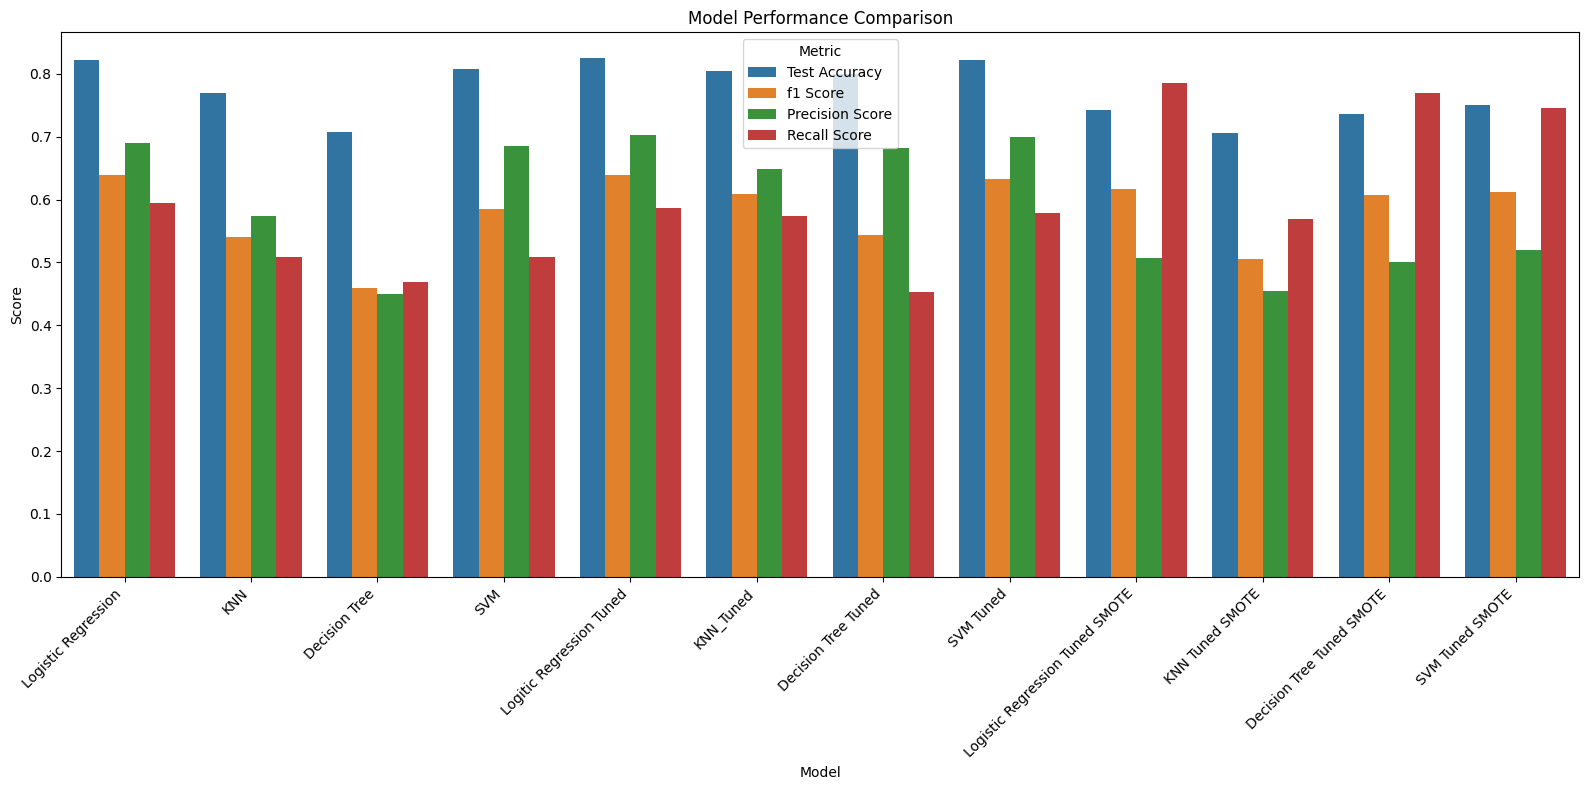

In [44]:
#Plotting the results
plot_df_1 = plot_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=plot_df_1)
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Impact of SMOTE on Model Performance

Overall SMOTE led to a decrease in test accuracy and preciison across all models. SMOTE successfully identified more churners but by classifying more non churners as churners. If identifying as many churners is important then SMOTE should be preferred

### Summary:
Data Analysis Key Findings

**Contract Type Impact:** Customers on month-to-month contracts show the highest churn rates, indicating a significant risk.

**Internet Service Influence:** Users of Fiber optic internet service show a high churn rate, suggesting potential dissatisfaction with this service type.

**Payment Method Correlation:** Electronic check users have a considerably higher churn rate compared to other payment methods.

**Ancillary Services Reduce Churn:** OnlineSecurity and TechSupport services significantly reduces the probability of customer churn.

**Tenure and Charges:** Newer customers or those with lower total charges are more likely to churn.

### Actionable Recommendations:
**Target Month-to-Month Contract Holders:** Customers on month-to-month contracts have the highest churn rate.Sending retention offers to this cohort and suggesting long term contracts or loyalty offers might help reduce the Churn.

**Fiber Optic Service Issues:** The high churn rate among Fiber optic internet service users suggests potential unhappiness. Deep dive into quality of service or frequent service disruptions to address the issue

**Electronic Check Payment:** Provide Incentives/discounts to move to electronic payment. This move might enable them to make timely payment and in turn improve their credit score.

**Promote Services:** Send messages to customers and train the customer reps to emphasize on security services. These services might significantly help reduce churn.

**Loyalty Programs for Long-Term Customers:** ensure continued satisfaction for long-term customers as they might be source of significant revenue to the company.



## Recommendations and Next Steps

Based on the data analysis, churn rate visualizations, and model performance comparison, here are recommendations for reducing customer churn and suggestions for model deployment or further analysis.

### Model Deployment and Further Analysis:

1.  **Model Selection**: The **Tuned Logistic Regression Model** demonstrated the best test accuracy (0.82) and efficiency. While SMOTE increased recall, it came at the cost of precision and overall accuracy, suggesting that the initial tuned Logistic Regression without SMOTE is preferable for a balanced view.

2. **Targeted Retention Strategies:** Implement proactive retention campaigns focused on month-to-month contract holders, Fiber optic internet users, and electronic check users, offering incentives to switch to longer contracts, addressing service quality, or promoting alternative payment methods.

3.  **Deployment**: Implement the chosen Logistic Regression model to predict churn risk for existing customers. This model can be scored and integrated with Loyalty offers and target customers who are at most risk of Churning. Combined with the contract type and fiber optics, precise customers can be targeted to reduce Churn.

4.  **Feature Importance Analysis**: Further analyze the feature importance from the Logistic Regression model to gain deeper insights into the specific factors driving churn. This can guide more precise offers.

5.  **Monitor Model Performance**: Continuously monitor the model's performance (accuracy, precision, recall) over time and retrain as new data becomes available, Cistomers behaviour changes over time with economic or political changes and it is very important to monitor the model for accuracy.

6.  **Cost-Benefit and Save rate Analysis**: Conduct a cost-benefit and save rate analysis of churn prevention efforts versus the lifetime value of a customer to ensure that retention strategies are economically feasible.